# LAPORAN DAN MODEL UAS KECERDASAN BUATAN
## PREDIKSI KUALITAS SUSU (MILK QUALITY PREDICTION) MENGGUNAKAN ALGORITMA DECISION TREE DAN K-NEAREST NEIGHBORS

**Dosen Pengampu:** Leni Fitriani, ST. M.Kom.  
**Program Studi:** Teknik Informatika  
**Jurusan:** Ilmu Komputer  
**Universitas:** Institut Teknologi Garut  

--- 
### **IDENTITAS KELOMPOK**
1. **SAYYID DZAKY FARHAN** - 2406007

---

In [1]:
# ========================================== 
# STEP 1: IMPORT LIBRARIES & LOAD DATASET
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('Data/Dataset/milknew.csv')

# Mengatasi whitespace pada nama kolom (Penting karena kolom 'Fat ' seringkali memiliki spasi bawaan)
df.columns = df.columns.str.strip()

print("--- Informasi Dasar Dataset ---")
print(f"Ukuran Dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")
df.info()

--- Informasi Dasar Dataset ---
Ukuran Dataset: 1059 baris, 8 kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pH          1059 non-null   float64
 1   Temprature  1059 non-null   int64  
 2   Taste       1059 non-null   int64  
 3   Odor        1059 non-null   int64  
 4   Fat         1059 non-null   int64  
 5   Turbidity   1059 non-null   int64  
 6   Colour      1059 non-null   int64  
 7   Grade       1059 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 66.3+ KB


In [2]:
# Menampilkan 5 data teratas
print("\n--- 5 Baris Pertama Data ---")
display(df.head())

# Statistik Deskriptif untuk data numerik
print("\n--- Statistik Deskriptif --- ")
display(df.describe())


--- 5 Baris Pertama Data ---


,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low
3,9.5,34,1,1,0,1,255,low
4,6.6,37,0,0,0,0,255,medium



--- Statistik Deskriptif --- 


,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000
mean,6.630123,44.226629,0.546742,0.432483,0.671388,0.491029,251.840415
std,1.399679,10.098364,0.498046,0.495655,0.469930,0.500156,4.307424
min,3.000000,34.000000,0.000000,0.000000,0.000000,0.000000,240.000000
25%,6.500000,38.000000,0.000000,0.000000,0.000000,0.000000,250.000000
50%,6.700000,41.000000,1.000000,0.000000,1.000000,0.000000,255.000000
75%,6.800000,45.000000,1.000000,1.000000,1.000000,1.000000,255.000000
max,9.500000,90.000000,1.000000,1.000000,1.000000,1.000000,255.000000


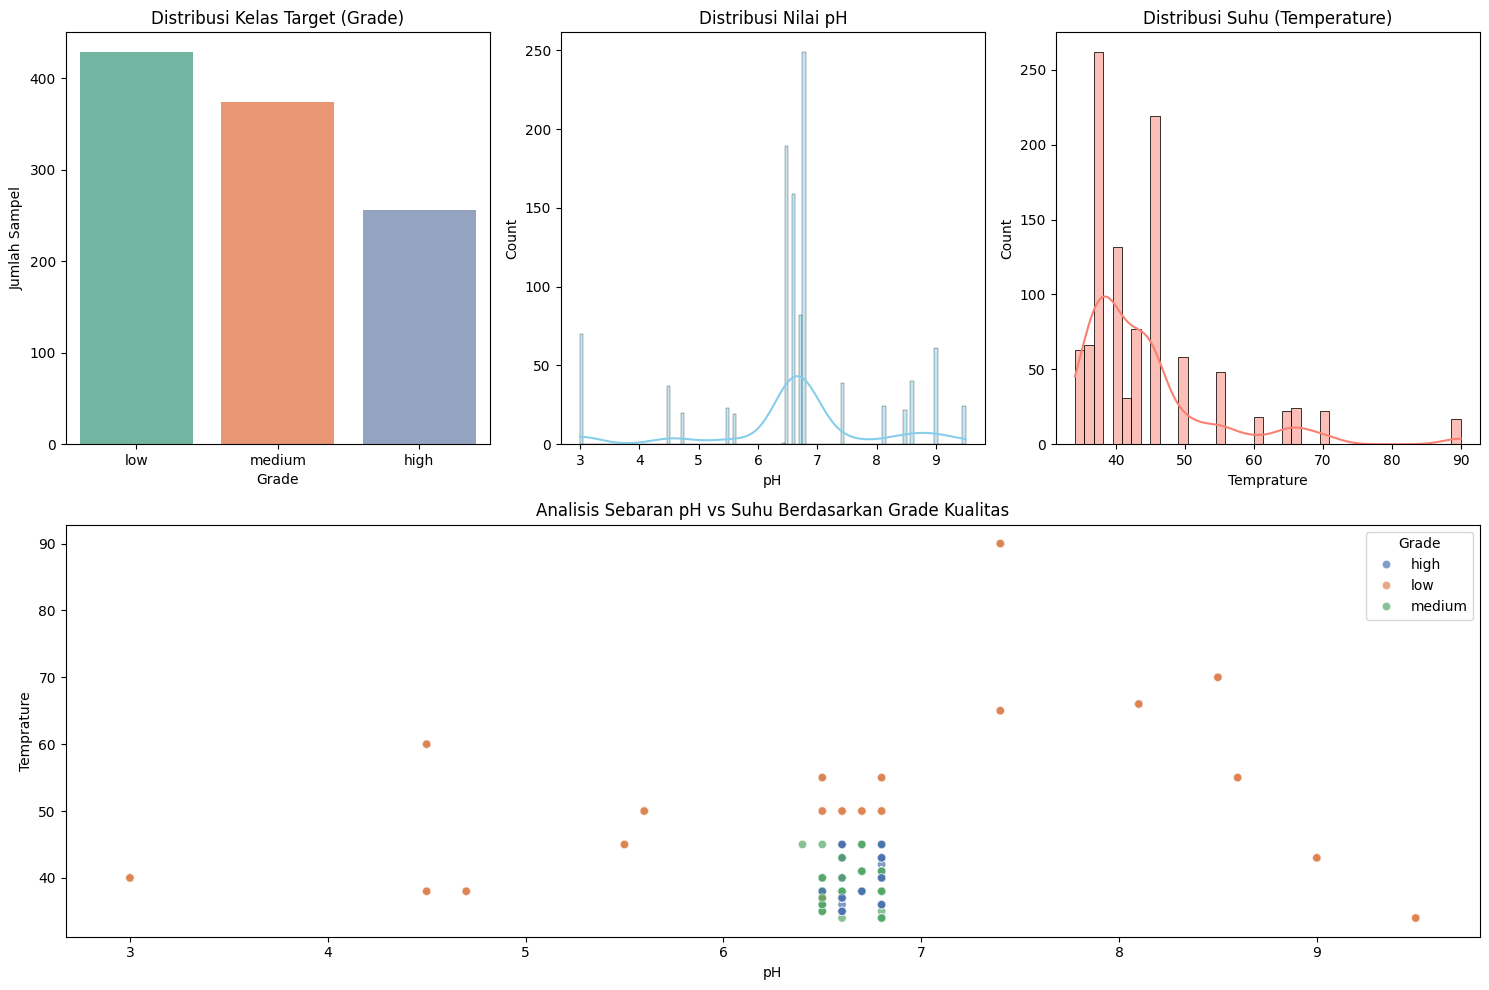

--- Distribusi Target Grade dalam Angka ---
Grade
low       429
medium    374
high      256
Name: count, dtype: int64


In [3]:
# ==========================================
# STEP 2: VISUALISASI DISTRIBUSI & KELAS
# ==========================================
plt.figure(figsize=(15, 10))

# 1. Visualisasi Kelas Target (Grade)
plt.subplot(2, 3, 1)
sns.countplot(x='Grade', data=df, order=['low', 'medium', 'high'], palette='Set2')
plt.title('Distribusi Kelas Target (Grade)')
plt.xlabel('Grade')
plt.ylabel('Jumlah Sampel')

# 2. Distribusi pH
plt.subplot(2, 3, 2)
sns.histplot(df['pH'], kde=True, color='skyblue')
plt.title('Distribusi Nilai pH')

# 3. Distribusi Temperature
plt.subplot(2, 3, 3)
sns.histplot(df['Temprature'], kde=True, color='salmon')
plt.title('Distribusi Suhu (Temperature)')

# 4. Hubungan pH vs Temprature berdasarkan Grade
plt.subplot(2, 1, 2)
sns.scatterplot(x='pH', y='Temprature', hue='Grade', data=df, palette='deep', alpha=0.7)
plt.title('Analisis Sebaran pH vs Suhu Berdasarkan Grade Kualitas')

plt.tight_layout()
plt.show()

print("--- Distribusi Target Grade dalam Angka ---")
print(df['Grade'].value_counts())

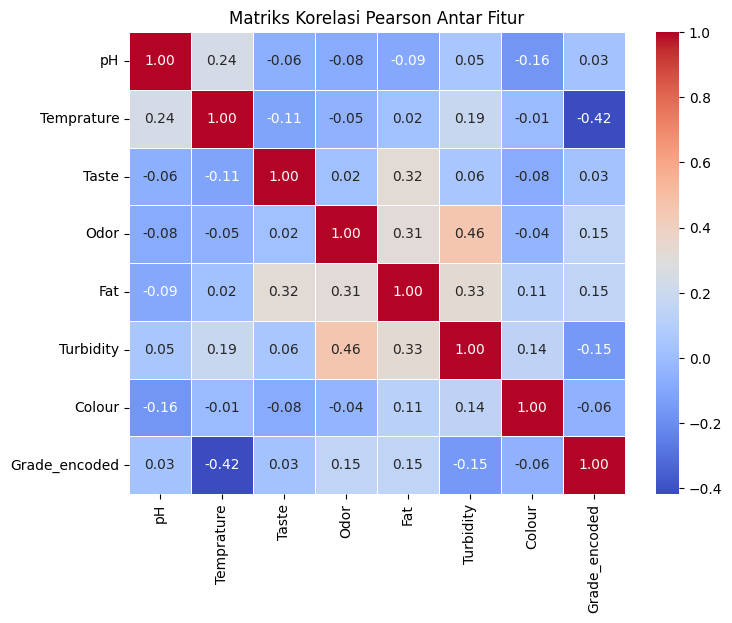

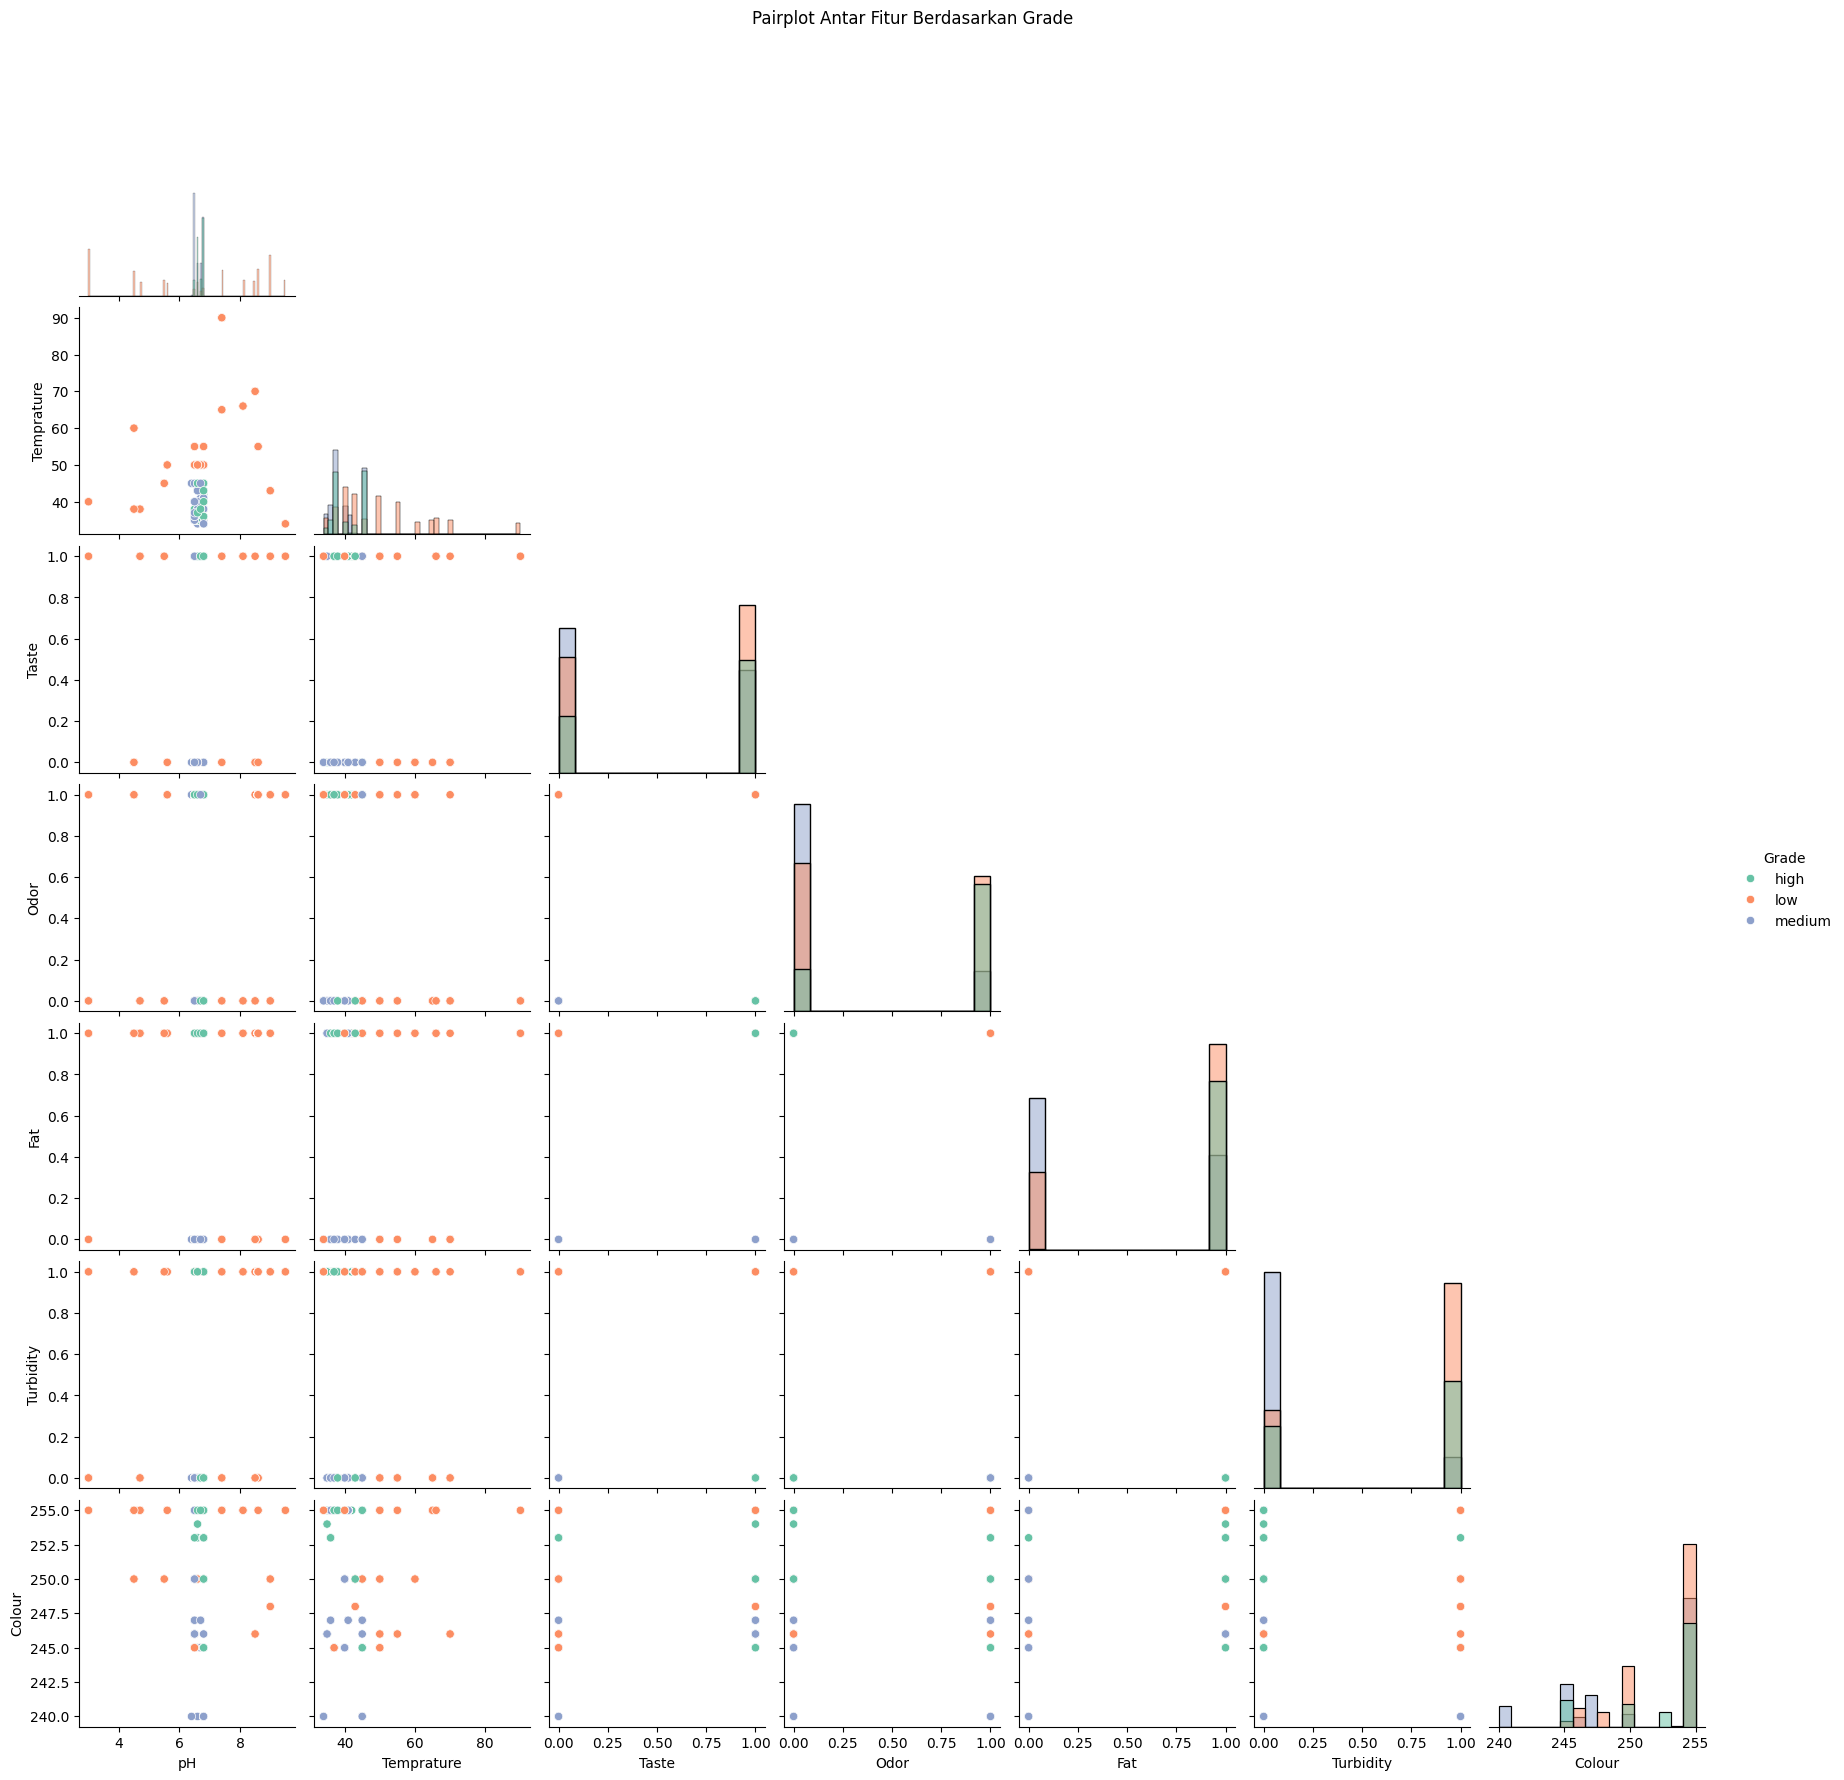

In [14]:
# 5. Analisis Korelasi Antar Fitur (Heatmap)
# Mengkodekan target secara sementara menjadi numerik agar dapat melihat korelasi linear
df_temp = df.copy()
df_temp['Grade_encoded'] = df_temp['Grade'].map({'low': 0, 'medium': 1, 'high': 2})

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_temp.drop('Grade', axis=1).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Matriks Korelasi Pearson Antar Fitur')
plt.show()

# Pairplot untuk melihat hubungan antar fitur
sns.pairplot(
    df,
    hue='Grade',          
    diag_kind='hist',     
    palette='Set2',
    corner=True           
)

plt.suptitle('Pairplot Antar Fitur Berdasarkan Grade', y=1.02)
plt.show()

### **Insight Awal dari Pola Data (EDA):**
1.  **Imbalanced Classes Check:** Dataset memiliki sebaran kelas target: `low` (429), `medium` (374), dan `high` (256). Kelas `high` memiliki jumlah paling sedikit, namun perbedaan jumlahnya tidak terlalu ekstrem (*moderate imbalance*), sehingga masih aman digunakan langsung.
2.  **Pola pH & Suhu:** Susu dengan kualitas tinggi (`high`) cenderung berkumpul pada rentang pH yang sangat ketat (sekitar 6.5 - 6.8) dan suhu yang ideal (35°C - 45°C). Di luar nilai pH tersebut (terlalu asam seperti < 5 atau terlalu basa seperti > 8) serta suhu ekstrem (> 55°C), kualitas susu langsung dikategorikan sebagai `low`.
3.  **Korelasi:** Kekeruhan (`Turbidity`), bau (`Odor`), dan kandungan lemak (`Fat`) memiliki hubungan korelasi positif yang cukup kuat satu sama lain.

In [5]:
# ==========================================
# STEP 3: DATA PREPROCESSING & CLEANING
# ==========================================
print("Jumlah nilai Null di setiap kolom:")
print(df.isnull().sum())

print(f"\nJumlah baris duplikat sebelum dibersihkan: {df.duplicated().sum()}")
# Catatan: Pada dataset survei/eksperimen kecil seperti ini, baris duplikat mencerminkan kesamaan parameter fisikokimia 
# hasil eksperimen berulang. Kita akan tetap mempertahankan data ini agar model dapat mengenali kombinasi nilai biner yang identik.

# Memisahkan Fitur (X) dan Target (y)
X = df.drop('Grade', axis=1)
y = df['Grade']

# Encoding label target: 'low' -> 0, 'medium' -> 1, 'high' -> 2
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nMapping Kelas Target: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Jumlah nilai Null di setiap kolom:
pH            0
Temprature    0
Taste         0
Odor          0
Fat           0
Turbidity     0
Colour        0
Grade         0
dtype: int64

Jumlah baris duplikat sebelum dibersihkan: 976

Mapping Kelas Target: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


In [6]:
# Split data menjadi Train Set (80%) dan Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ukuran Training Set: {X_train.shape[0]} baris")
print(f"Ukuran Testing Set: {X_test.shape[0]} baris")

Ukuran Training Set: 847 baris
Ukuran Testing Set: 212 baris


In [7]:
# ==========================================
# STEP 4: TRAINING MODEL
# ==========================================

# 1. Inisialisasi dan Pelatihan Model Decision Tree
# Menggunakan max_depth=5 untuk mencegah overfitting agar pohon keputusan tetap mudah dibaca
dt_model = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 2. Inisialisasi dan Pelatihan Model KNN
# Menggunakan k=5 sebagai nilai standar default tetangga terdekat
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_model.fit(X_train_scaled, y_train)

print("Proses pelatihan kedua model telah selesai dengan sukses!")

Proses pelatihan kedua model telah selesai dengan sukses!


In [8]:
# ==========================================
# STEP 5: PREDIKSI DAN EVALUASI KINERJA
# ==========================================

y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

# Fungsi pembantu untuk menghitung metrik evaluasi secara berkala
def get_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    return [accuracy, precision, recall, f1]

metrics_dt = get_metrics(y_test, y_pred_dt)
metrics_knn = get_metrics(y_test, y_pred_knn)

# Membuat DataFrame Perbandingan Performa
df_comparison = pd.DataFrame({
    'Metrik Evaluasi': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Decision Tree': metrics_dt,
    'K-Nearest Neighbors (KNN)': metrics_knn
})

print("--- Tabel Perbandingan Kinerja Model ---")
display(df_comparison)

--- Tabel Perbandingan Kinerja Model ---


,Metrik Evaluasi,Decision Tree,K-Nearest Neighbors (KNN)
0,Accuracy,0.882075,0.995283
1,Precision (Macro),0.907287,0.993590
2,Recall (Macro),0.839261,0.996124
3,F1-Score (Macro),0.846588,0.994814


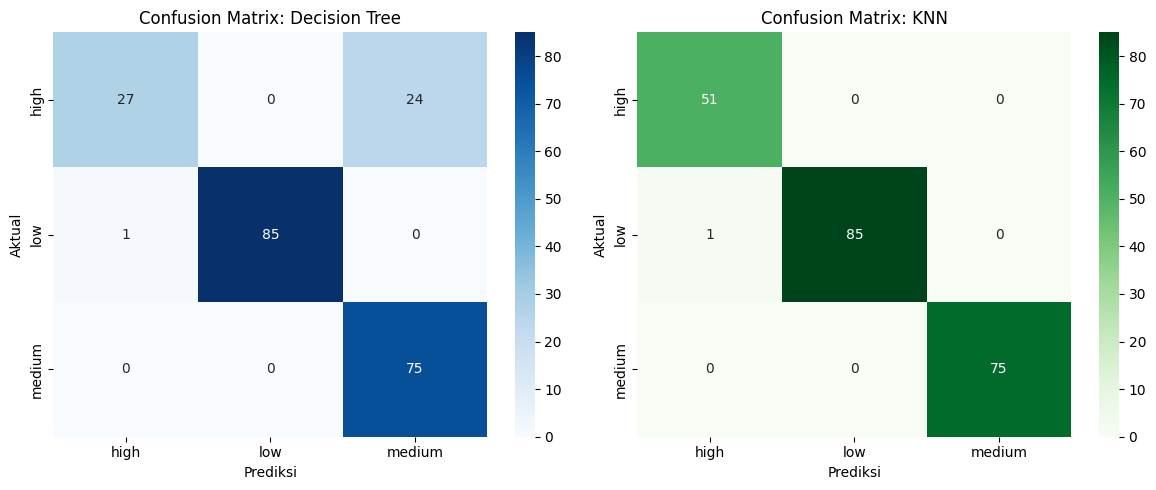

In [9]:
# Visualisasi Confusion Matrix untuk kedua Model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

plt.subplot(1, 2, 2)
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: KNN')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

plt.tight_layout()
plt.show()

In [10]:
# Menampilkan Laporan Klasifikasi Detail
print("=================== REPORT DETAIL DECISION TREE ===================")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

print("\n=================== REPORT DETAIL KNN ===================")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

=================== REPORT DETAIL DECISION TREE ===================
              precision    recall  f1-score   support

        high       0.96      0.53      0.68        51
         low       1.00      0.99      0.99        86
      medium       0.76      1.00      0.86        75

    accuracy                           0.88       212
   macro avg       0.91      0.84      0.85       212
weighted avg       0.91      0.88      0.87       212


=================== REPORT DETAIL KNN ===================
              precision    recall  f1-score   support

        high       0.98      1.00      0.99        51
         low       1.00      0.99      0.99        86
      medium       1.00      1.00      1.00        75

    accuracy                           1.00       212
   macro avg       0.99      1.00      0.99       212
weighted avg       1.00      1.00      1.00       212



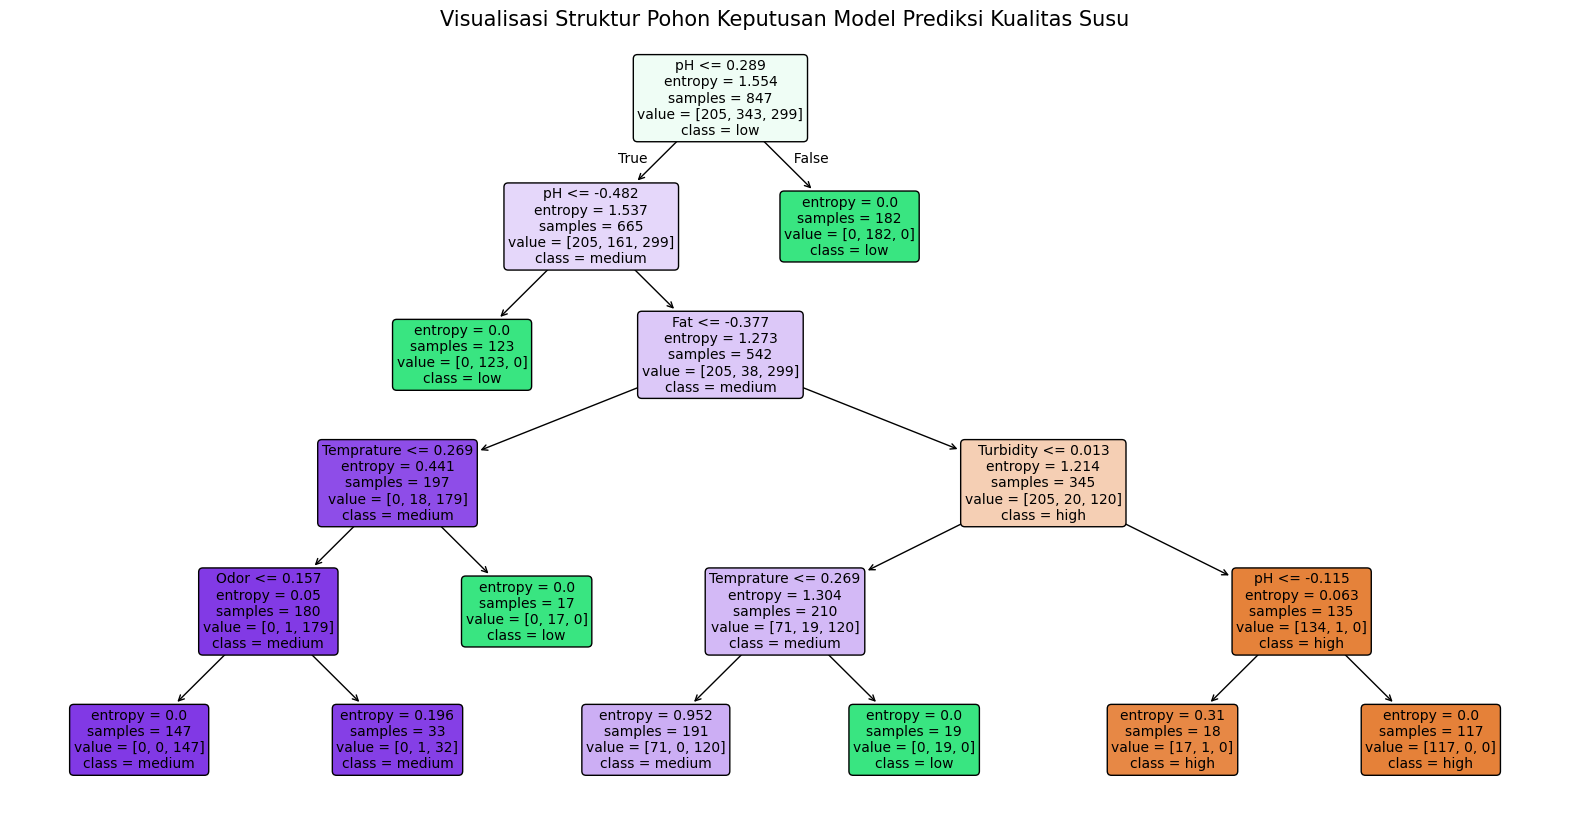

In [11]:
# Visualisasi Pohon Keputusan (Decision Tree Structure)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=le.classes_, filled=True, rounded=True, fontsize=10)
plt.title('Visualisasi Struktur Pohon Keputusan Model Prediksi Kualitas Susu', fontsize=15)
plt.show()